# 📈 Sales Prediction using Machine Learning

## Introduction

Sales prediction is one of the most important applications of machine learning in marketing and business analytics. Organizations invest heavily in different advertising platforms such as TV, Radio, and Newspaper to promote their products. Predicting future sales based on advertising expenditure helps businesses optimize their marketing budget, maximize return on investment (ROI), and improve decision-making.

In this project, a regression-based machine learning model is developed to predict product sales using advertising expenditure across different marketing channels. The project includes data preprocessing, exploratory data analysis (EDA), feature engineering, model building, evaluation, and prediction using multiple regression algorithms.

## Objectives

- Analyze the advertising dataset.
- Understand the relationship between advertising expenditure and sales.
- Clean and preprocess the dataset.
- Perform exploratory data analysis (EDA).
- Train multiple regression models.
- Compare model performance using evaluation metrics.
- Predict future sales based on advertising budgets.
- Generate business insights to improve marketing strategies.

#Import Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RandomizedSearchCV

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)

import joblib

#Load Dataset

In [3]:
df = pd.read_csv("Advertising.csv")

df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [4]:
df.tail()

,Unnamed: 0,TV,Radio,Newspaper,Sales
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5
199,200,232.1,8.6,8.7,13.4


* The dataset contains 200 records and includes features such as TV, Radio, Newspaper, and Sales.

In [5]:
print("Shape :",df.shape)

Shape : (200, 5)


The dataset contains 200 rows and 5 columns.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


* The dataset contains 200 records and 5 columns, including advertising and sales data.
* There are no missing values, as all columns have 200 non-null entries.
* The dataset includes 4 numerical features and is ready for data analysis and sales prediction.

In [7]:
df.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


* The average TV advertising budget is 147.04, while the average Sales is 14.02.
* The advertising budget ranges from 0.7 to 296.4 for TV, 0 to 49.6 for Radio, and 0.3 to 114 for Newspaper.
* Sales range from 1.6 to 27.0, showing a wide variation in sales performance across different advertising budgets.

In [8]:
df.isnull().sum()

,0
Unnamed: 0,0
TV,0
Radio,0
Newspaper,0
Sales,0


* There no any missing value in dataset.

In [9]:
df.duplicated().sum()

np.int64(0)

* There no any duplicate value in dataset.

In [10]:
df.columns

Index(['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

In [11]:
df.dtypes

,0
Unnamed: 0,int64
TV,float64
Radio,float64
Newspaper,float64
Sales,float64


In [12]:
if "Unnamed: 0" in df.columns:
    df.drop("Unnamed: 0", axis=1, inplace=True)

In [13]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


# Exploratory Data Analysis (EDA)

## Distribution Plots

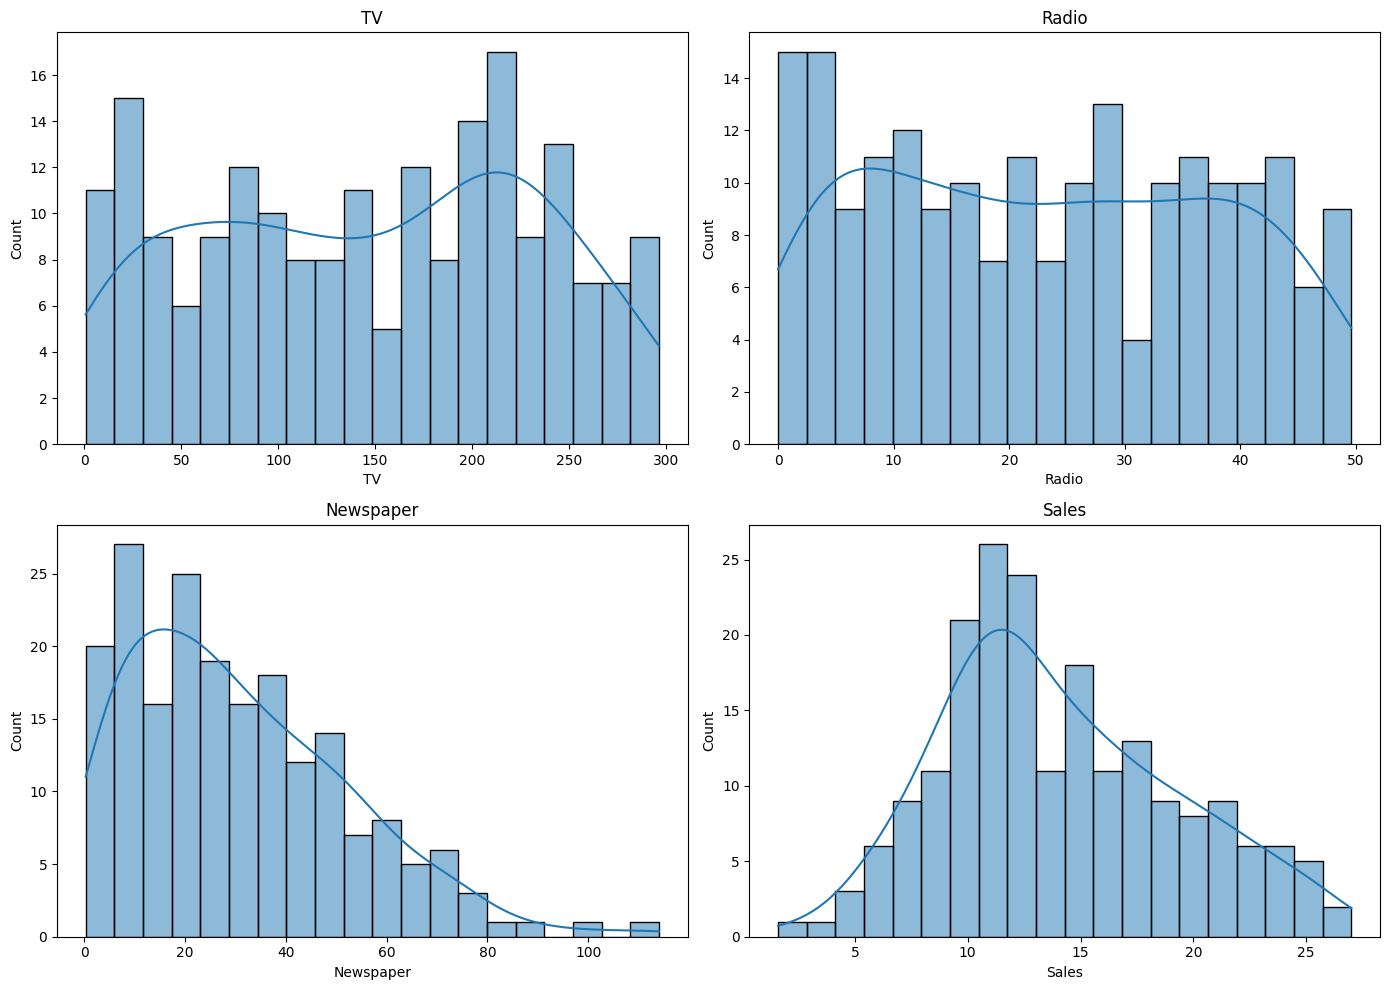

In [14]:
num_cols=df.select_dtypes(include=np.number).columns

plt.figure(figsize=(14,10))

for i,col in enumerate(num_cols,1):

    plt.subplot(2,2,i)

    sns.histplot(df[col],kde=True,bins=20)

    plt.title(col)

plt.tight_layout()

plt.show()

* TV and Radio advertising budgets are fairly well distributed across different spending levels.
* Newspaper advertising is right-skewed, with most businesses spending lower amounts and only a few spending very high amounts.
* Sales are mostly concentrated between 10 and 15 units, with fewer observations at very low or very high sales values.

## Box Plots

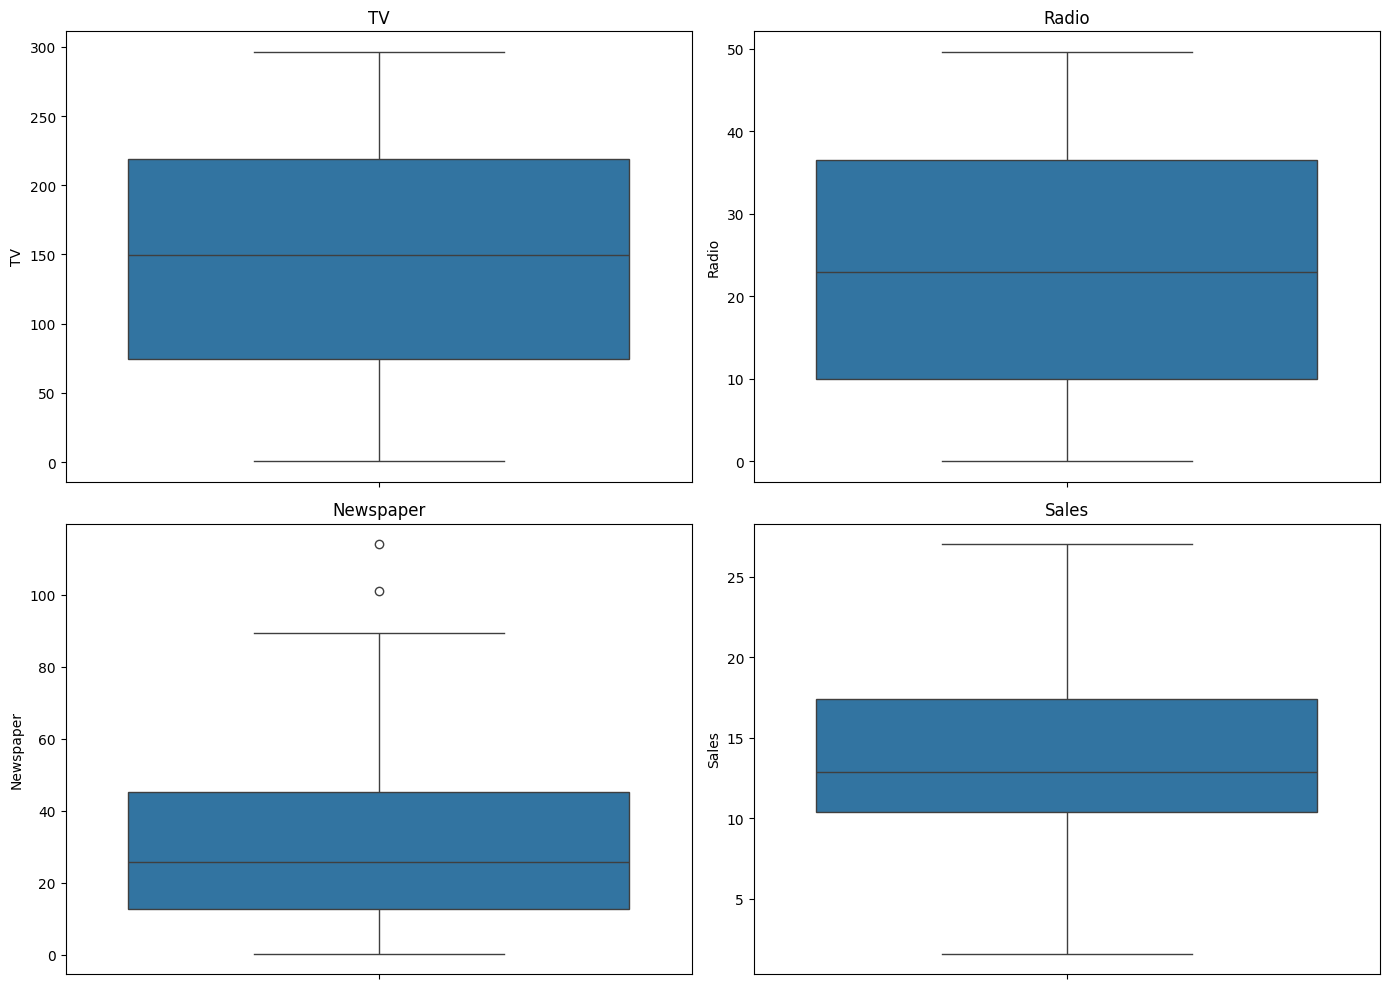

In [15]:
plt.figure(figsize=(14,10))

for i,col in enumerate(num_cols,1):

    plt.subplot(2,2,i)

    sns.boxplot(y=df[col])

    plt.title(col)

plt.tight_layout()

plt.show()

* TV, Radio, and Sales do not show significant outliers, indicating that most values are within a normal range.

## Pairplot

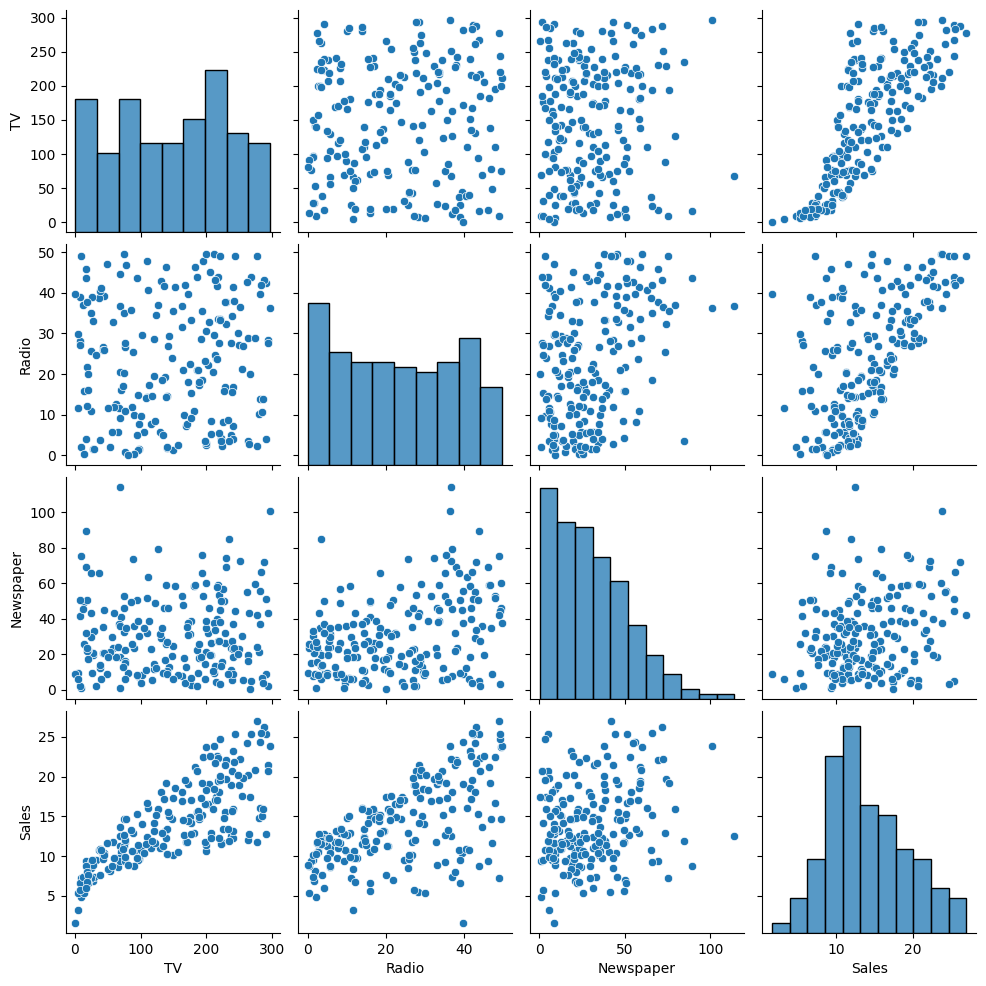

In [16]:
sns.pairplot(df)

plt.show()

* TV advertising has a strong positive relationship with Sales, indicating that higher TV spending generally increases sales.
* Radio advertising also shows a positive relationship with Sales, but it is weaker than TV.
* Newspaper advertising has a weak relationship with Sales, suggesting it has less impact on sales prediction.

## Correlation Heatmap

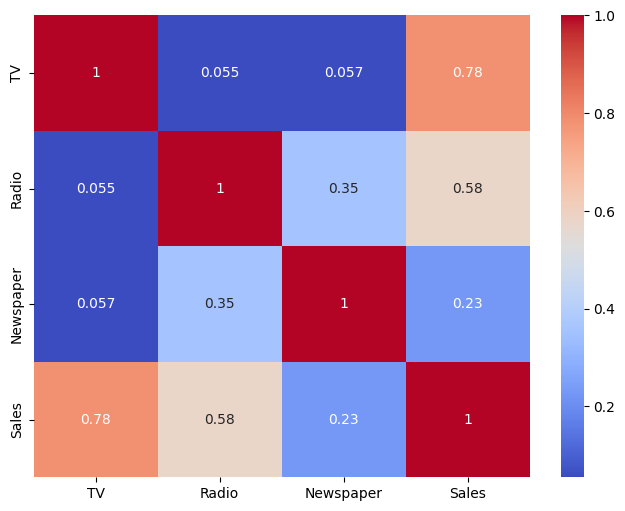

In [17]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

* TV has the strongest positive correlation (0.78) with Sales, making it the most influential advertising channel.
* Radio shows a moderate positive correlation (0.58) with Sales, indicating it also contributes to increasing sales.
* Newspaper has a weak positive correlation (0.23) with Sales, suggesting it has the least impact on sales prediction.

## Regression Plots

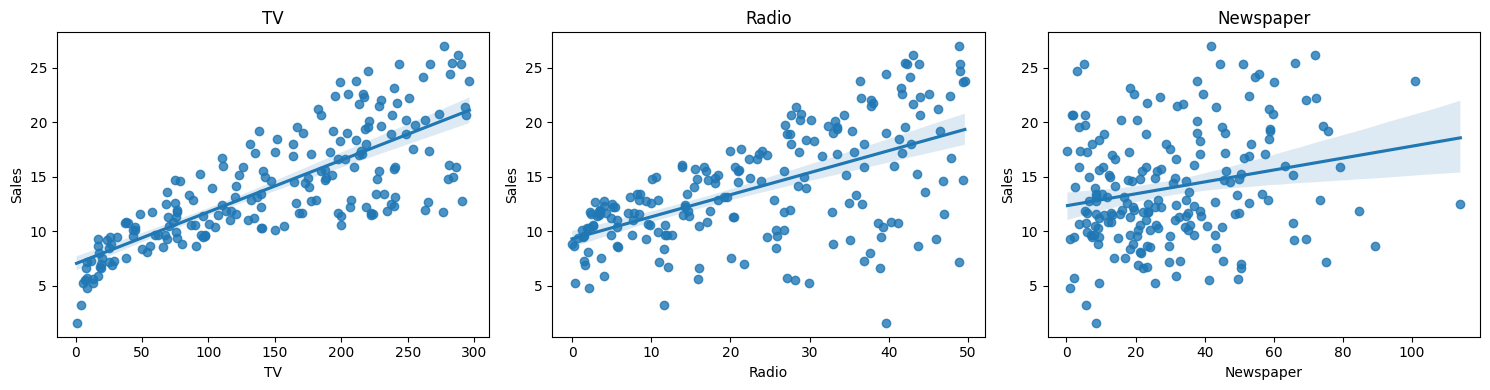

In [18]:
features=["TV","Radio","Newspaper"]

plt.figure(figsize=(15,4))

for i,col in enumerate(features,1):

    plt.subplot(1,3,i)

    sns.regplot(
        x=df[col],
        y=df["Sales"]
    )

    plt.title(col)

plt.tight_layout()

plt.show()

* TV advertising shows the strongest positive relationship with Sales, indicating higher TV spending leads to higher sales.
* Radio advertising also has a positive relationship with Sales, but it is weaker than TV.
* Newspaper advertising has a weak relationship with Sales, suggesting it has the least impact on increasing sales.

## Feature Selection

In [19]:
X=df.drop("Sales",axis=1)

y=df["Sales"]

## Train Test Split

In [21]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42)

##Train Models

In [23]:
models={

"Linear Regression":LinearRegression(),

"Decision Tree":DecisionTreeRegressor(random_state=42),

"Random Forest":RandomForestRegressor(random_state=42),

"Gradient Boosting":GradientBoostingRegressor(random_state=42)

}


In [24]:

results=[]

for name,model in models.items():

    model.fit(X_train,y_train)

    pred=model.predict(X_test)

    mae=mean_absolute_error(y_test,pred)

    mse=mean_squared_error(y_test,pred)

    rmse=np.sqrt(mse)

    r2=r2_score(y_test,pred)

    results.append([name,mae,mse,rmse,r2])

    print("="*60)

    print(name)

    print("MAE :",mae)

    print("MSE :",mse)

    print("RMSE :",rmse)

    print("R2 :",r2)

Linear Regression
MAE : 1.4607567168117603
MSE : 3.1740973539761033
RMSE : 1.78159966153345
R2 : 0.899438024100912
Decision Tree
MAE : 0.9850000000000001
MSE : 2.175
RMSE : 1.4747881203752624
R2 : 0.9310914968293178
Random Forest
MAE : 0.6200999999999988
MSE : 0.5907322499999988
RMSE : 0.7685910811348248
R2 : 0.9812843792541843
Gradient Boosting
MAE : 0.618742412127568
MSE : 0.5325817328183275
RMSE : 0.7297819762218902
R2 : 0.9831267080346855


* Gradient Boosting performed the best with the highest R² Score (0.9831) and the lowest RMSE (0.73).
* Random Forest also achieved excellent performance with an R² Score of 0.9813, making it the second-best model.
* Linear Regression and Decision Tree performed well, but their prediction accuracy was lower compared to Gradient Boosting and Random Forest.

#Comparison  Table

In [25]:
comparison=pd.DataFrame(
results,
columns=[
"Model",
"MAE",
"MSE",
"RMSE",
"R2 Score"
])

comparison

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,1.460757,3.174097,1.781600,0.899438
1,Decision Tree,0.985000,2.175000,1.474788,0.931091
2,Random Forest,0.620100,0.590732,0.768591,0.981284
3,Gradient Boosting,0.618742,0.532582,0.729782,0.983127


* Gradient Boosting is the best-performing model with the highest R² Score (0.9831) and the lowest prediction errors (MAE, MSE, and RMSE).
* Random Forest also provides excellent performance, achieving an R² Score of 0.9813, very close to Gradient Boosting.
* Linear Regression and Decision Tree perform well, but they are less accurate than Gradient Boosting and Random Forest for sales prediction.

# Hyperparameter Tuning

In [27]:
params={"n_estimators":[100,200,300],"max_depth":[5,10,15,None],
"min_samples_split":[2,5,10],"min_samples_leaf":[1,2,4]}

search=RandomizedSearchCV(
RandomForestRegressor(random_state=42),
param_distributions=params,
cv=5,
n_iter=20,
random_state=42,
n_jobs=-1
)

search.fit(X_train,y_train)

best_model=search.best_estimator_

print(search.best_params_)

{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}


# Cross Validation

In [28]:
scores=cross_val_score(best_model,X,y,cv=5,scoring="r2")

print(scores)
print(scores.mean())

[0.98130621 0.98444173 0.97006047 0.96226536 0.98134742]
0.9758842372682345


#Feature Importance

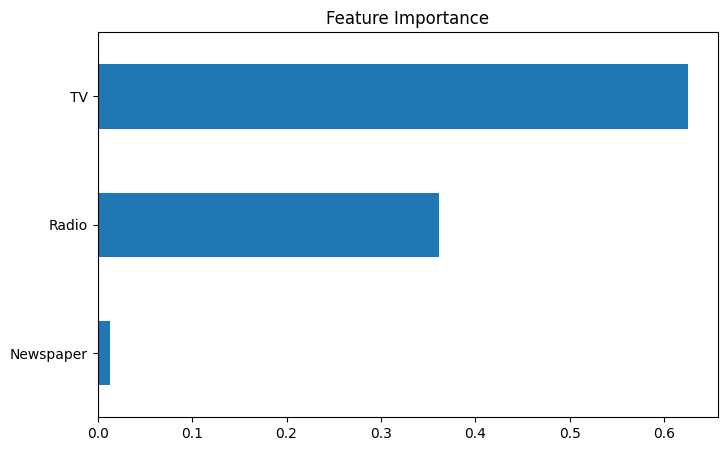

In [29]:
importance=pd.Series(best_model.feature_importances_,index=X.columns)

importance.sort_values().plot(kind="barh",figsize=(8,5))

plt.title("Feature Importance")

plt.show()

* TV advertising is the most important feature for predicting sales.
* Radio advertising has the second-highest importance and also contributes significantly to sales prediction.
* Newspaper advertising has very low importance, indicating it has minimal impact on predicting sales.

# Actual vs Predicted

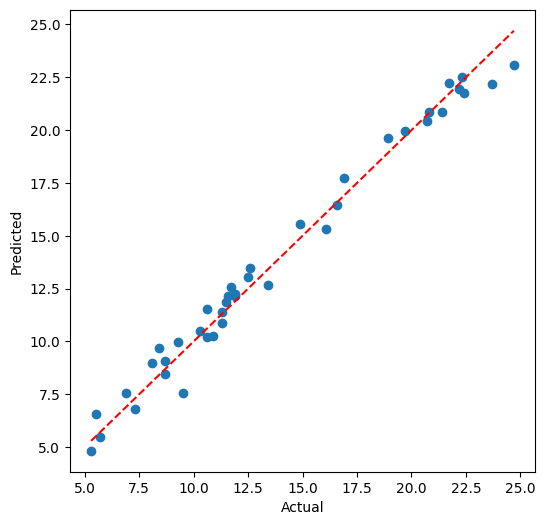

In [30]:
prediction=best_model.predict(X_test)

plt.figure(figsize=(6,6))

plt.scatter(
y_test,
prediction
)

plt.plot(
[y_test.min(),y_test.max()],
[y_test.min(),y_test.max()],
'r--'
)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.show()

* Most predicted values are very close to the actual values, indicating high prediction accuracy.
* The data points lie close to the red diagonal line, showing that the model fits the data well.
* Only a few points deviate from the line, indicating small prediction errors for some observations.

# Residual Plot

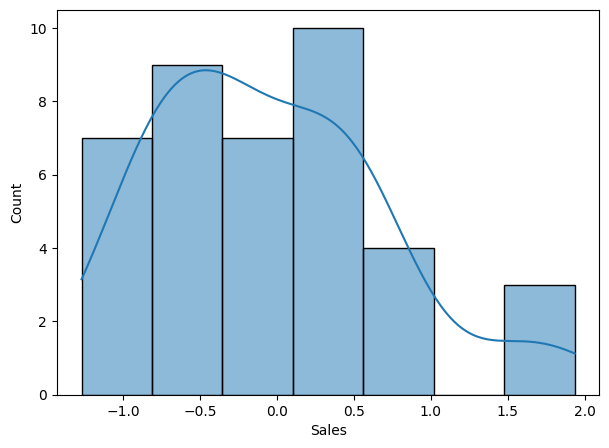

In [31]:
residual=y_test-prediction

plt.figure(figsize=(7,5))

sns.histplot(
residual,
kde=True
)

plt.show()

* Most residual values are close to 0, indicating that the model makes accurate predictions.
* The residuals are approximately centered around zero, showing no significant prediction bias.
* A few residuals are farther from zero, indicating small prediction errors for some sales values.

# Predict Future Sales

In [38]:
sample=pd.DataFrame({"TV":[250],"Radio":[35],"Newspaper":[45]})

prediction=best_model.predict(sample)

print("Predicted Sales :",prediction[0])

Predicted Sales : 21.09333333333334


# Save Model

In [36]:
joblib.dump(best_model,"sales_prediction_model.pkl")

['sales_prediction_model.pkl']

In [37]:
loaded_model=joblib.load("sales_prediction_model.pkl")

# Conclusion

This project successfully developed a machine learning model to predict product sales using advertising expenditure on TV, Radio, and Newspaper platforms. The dataset was explored, cleaned, and analyzed through comprehensive exploratory data analysis to understand the relationship between advertising investment and sales performance.

Multiple regression algorithms were trained and evaluated using MAE, MSE, RMSE, and R² Score. Hyperparameter tuning and cross-validation were performed to improve model reliability and generalization. Feature importance analysis revealed that TV advertising had the strongest influence on sales, followed by Radio, while Newspaper advertising had the least impact.

The trained model can be used by businesses to estimate future sales based on planned advertising budgets, optimize marketing investments, and support data-driven decision-making. This project demonstrates the complete machine learning workflow, from data preprocessing to model deployment, making it suitable for real-world business applications.